In [46]:
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [47]:
df = pd.read_csv('cars_data.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Manufacturer
0,I10,2017,7495.0,Manual,11630,Petrol,145,60.1,1.0,hyundi
1,Polo,2017,10989.0,Manual,9200,Petrol,145,58.9,1.0,volkswagen
2,2 Series,2019,27990.0,Semi-Auto,1614,Diesel,145,49.6,2.0,BMW
3,Yeti Outdoor,2017,12495.0,Manual,30960,Diesel,150,62.8,2.0,skoda
4,Fiesta,2017,7999.0,Manual,19353,Petrol,125,54.3,1.2,ford


In [48]:
df.shape

(97712, 10)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97712 entries, 0 to 97711
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         97712 non-null  str    
 1   year          97712 non-null  int64  
 2   price         96727 non-null  float64
 3   transmission  97712 non-null  str    
 4   mileage       97712 non-null  int64  
 5   fuelType      93586 non-null  str    
 6   tax           97712 non-null  int64  
 7   mpg           94256 non-null  float64
 8   engineSize    97712 non-null  float64
 9   Manufacturer  97712 non-null  str    
dtypes: float64(3), int64(3), str(4)
memory usage: 7.5 MB


In [50]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,97712.000000,96727.000000,97712.000000,97712.000000,94256.000000,97712.000000
mean,2017.066502,16774.299823,23219.475499,120.142408,55.228326,1.664913
std,2.118661,9874.715050,21060.882301,63.357250,16.296400,0.558574
min,1970.000000,450.000000,1.000000,0.000000,0.300000,0.000000
25%,2016.000000,9999.000000,7673.000000,125.000000,47.100000,1.200000
50%,2017.000000,14471.000000,17682.500000,145.000000,54.300000,1.600000
75%,2019.000000,20750.000000,32500.000000,145.000000,62.800000,2.000000
max,2024.000000,159999.000000,323000.000000,580.000000,470.800000,6.600000


#EDA

In [51]:
df.isnull().sum()

model              0
year               0
price            985
transmission       0
mileage            0
fuelType        4126
tax                0
mpg             3456
engineSize         0
Manufacturer       0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(1)

In [53]:
df.drop_duplicates(inplace=True)

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df["fuelType"] = df["fuelType"].fillna(df["fuelType"].mode()[0])

In [56]:
df["mpg"] = df["mpg"].fillna(df["mpg"].mean())

In [57]:
df = df.dropna(subset=["price"])

In [58]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
Manufacturer    0
dtype: int64

<Axes: >

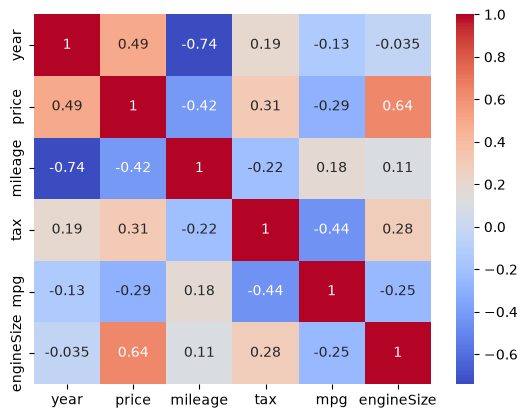

In [59]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

<Axes: xlabel='price', ylabel='Count'>

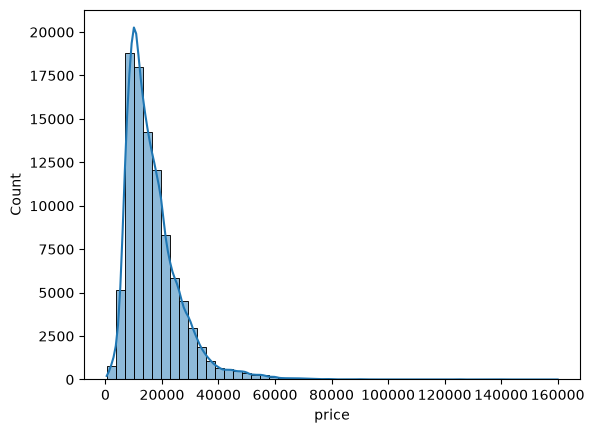

In [60]:
sns.histplot(df["price"], bins=50, kde=True)

In [61]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize', 'Manufacturer'],
      dtype='str')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, '1970'),
  Text(1, 0, '1996'),
  Text(2, 0, '1997'),
  Text(3, 0, '1998'),
  Text(4, 0, '1999'),
  Text(5, 0, '2000'),
  Text(6, 0, '2001'),
  Text(7, 0, '2002'),
  Text(8, 0, '2003'),
  Text(9, 0, '2004'),
  Text(10, 0, '2005'),
  Text(11, 0, '2006'),
  Text(12, 0, '2007'),
  Text(13, 0, '2008'),
  Text(14, 0, '2009'),
  Text(15, 0, '2010'),
  Text(16, 0, '2011'),
  Text(17, 0, '2012'),
  Text(18, 0, '2013'),
  Text(19, 0, '2014'),
  Text(20, 0, '2015'),
  Text(21, 0, '2016'),
  Text(22, 0, '2017'),
  Text(23, 0, '2018'),
  Text(24, 0, '2019'),
  Text(25, 0, '2020'),
  Text(26, 0, '2024')])

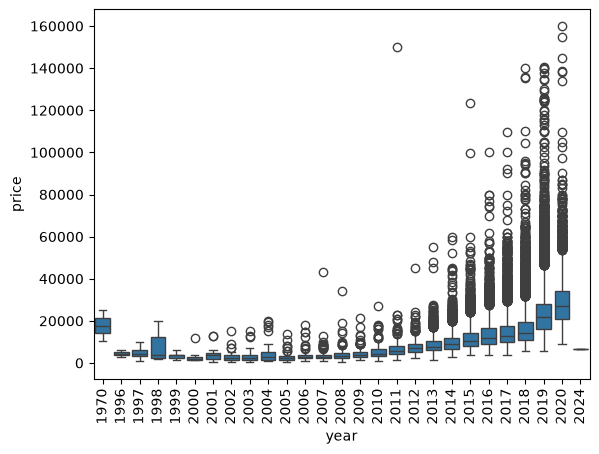

In [62]:
sns.boxplot(y=df["price"], x=df["year"])
plt.xticks(rotation=90)


<Axes: xlabel='transmission', ylabel='price'>

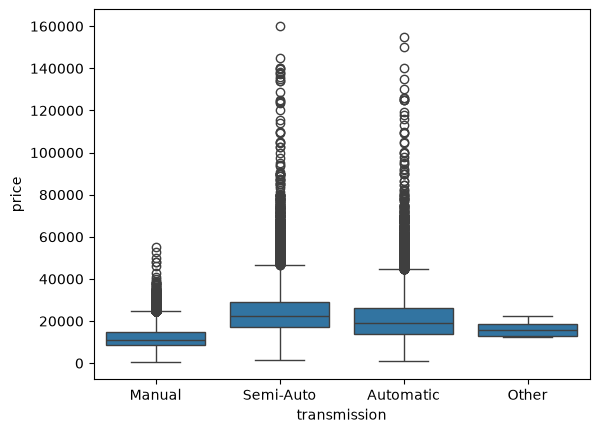

In [63]:
sns.boxplot(y=df["price"], x=df["transmission"])

<Axes: xlabel='Manufacturer', ylabel='price'>

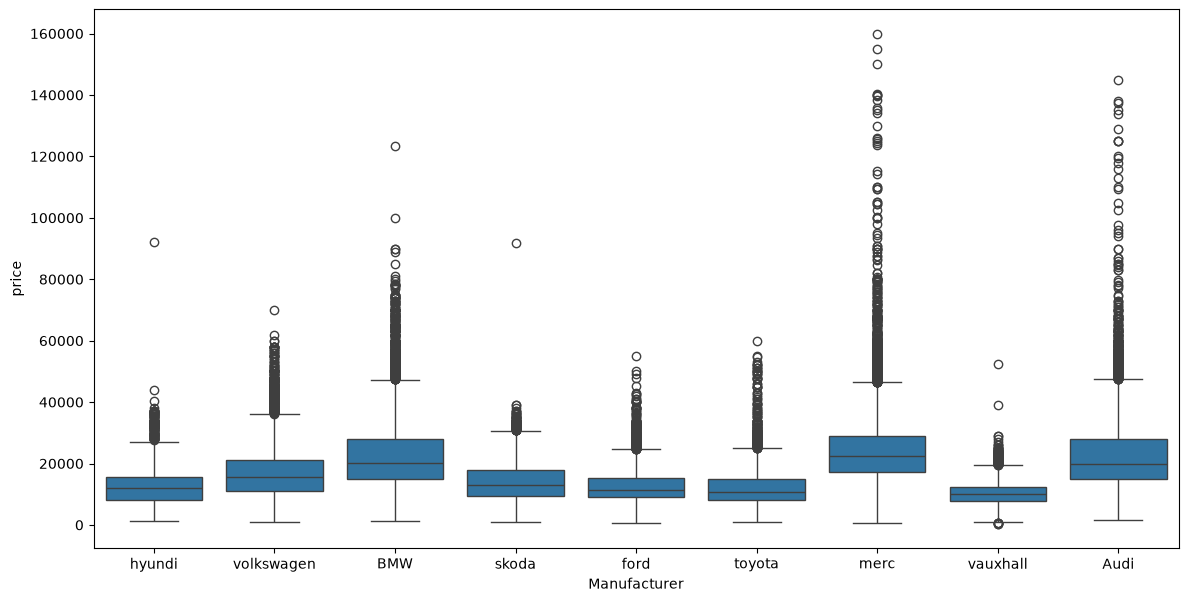

In [64]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Manufacturer",
    y="price"
)

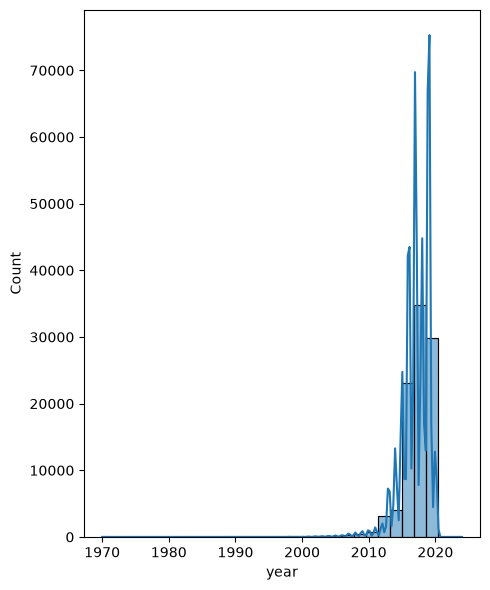

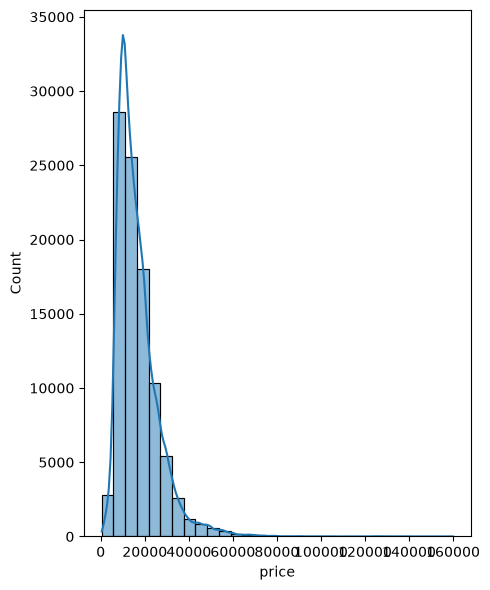

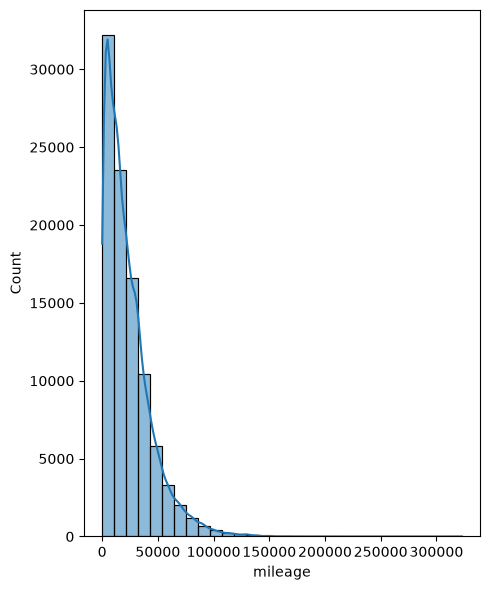

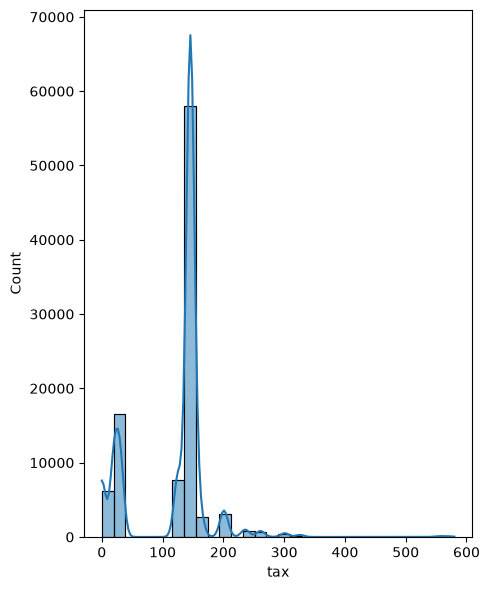

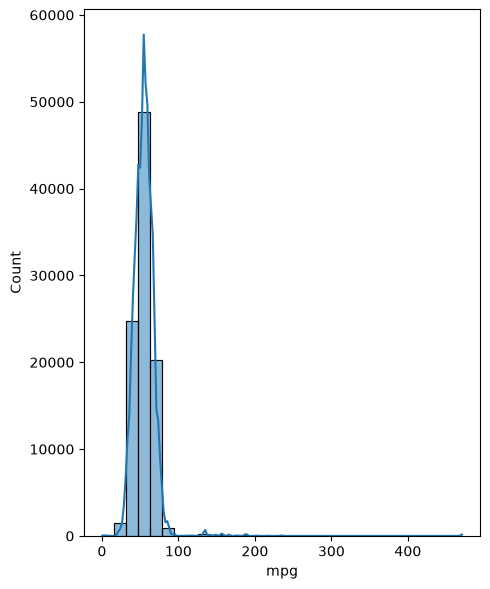

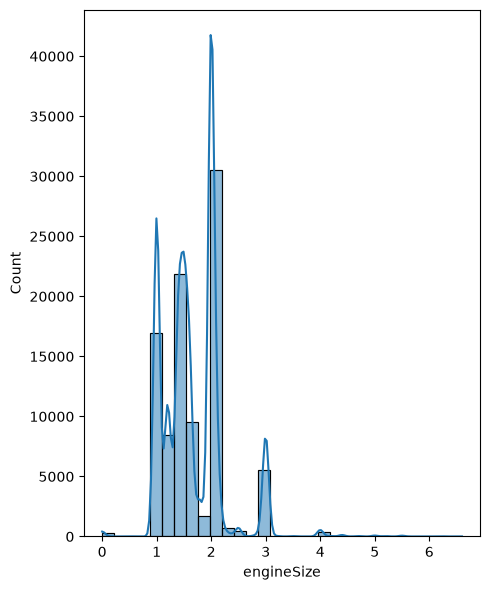

In [65]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

for cols in num_cols:
    plt.figure(figsize=(5,6))
    sns.histplot(df[cols], kde=True, bins=30)
    plt.tight_layout()

In [66]:
df[df["engineSize"] == 0][
    ["Manufacturer", "year", "price", "mileage", "mpg", "engineSize"]
]

,Manufacturer,year,price,mileage,mpg,engineSize
449,BMW,2017,19895.0,29851,470.8,0.0
969,BMW,2016,14900.0,59945,470.8,0.0
1985,BMW,2018,18000.0,24240,64.2,0.0
2219,vauxhall,2017,11000.0,14878,51.4,0.0
3290,hyundi,2015,7500.0,13637,57.6,0.0
...,...,...,...,...,...,...
95623,ford,2018,12999.0,15000,58.9,0.0
95625,hyundi,2017,11400.0,12661,44.1,0.0
96910,ford,2013,5328.0,105000,65.7,0.0
97033,hyundi,2016,6300.0,17272,61.4,0.0


In [67]:
df["engineSize"] = df["engineSize"].replace(0, np.nan)

In [68]:
high_mpg = df[df["mpg"] > 100]

high_mpg[
    ["Manufacturer", "year", "price", "mileage", "tax", "mpg", "engineSize"]
].sort_values("mpg", ascending=False).head(30)

,Manufacturer,year,price,mileage,tax,mpg,engineSize
449,BMW,2017,19895.0,29851,0,470.8,NaN
78929,BMW,2017,18999.0,20321,135,470.8,NaN
3506,BMW,2017,19998.0,41146,0,470.8,NaN
4759,BMW,2017,22495.0,21025,0,470.8,NaN
47798,BMW,2014,15450.0,42479,0,470.8,NaN
11129,BMW,2016,17000.0,41063,0,470.8,0.6
10959,BMW,2017,19000.0,23983,0,470.8,NaN
11088,BMW,2017,21490.0,26139,135,470.8,NaN
17005,BMW,2014,14182.0,37161,0,470.8,NaN
85131,BMW,2017,20000.0,19178,0,470.8,0.6


In [69]:
(df["mpg"] > 400).sum()

np.int64(43)

In [70]:
df[df["mpg"] > 100]["Manufacturer"].value_counts()

Manufacturer
BMW           258
merc          120
volkswagen     93
Audi           31
toyota         30
skoda          17
ford            4
hyundi          3
vauxhall        3
Name: count, dtype: int64

In [71]:
df[df["mpg"] > 100]["mpg"].value_counts().sort_index()

mpg
100.9      3
113.0      9
117.7     13
122.8      3
122.9      1
128.4      1
134.5    183
135.5      5
141.2     18
141.3     14
148.7     41
156.9     75
166.0     20
166.2     18
176.6     14
188.3     60
201.8      9
217.3     10
235.0     13
235.4      3
256.8      3
470.8     43
Name: count, dtype: int64

price is the continuous target.
Manufacturer has different price distributions.
year has a relationship with price.
mileage, tax, mpg, and engineSize show varying relationships with price.
Numerical variables contain outliers.
engineSize = 0 was treated as missing.
mpg = 470.8 was treated as an invalid/suspicious value and replaced with missing.
Missing numerical values will be handled through median imputation.

# Preprocessing

In [72]:
from sklearn.model_selection import train_test_split
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['year', 'mileage', 'tax', 'mpg', 'engineSize']
Categorical: ['model', 'transmission', 'fuelType', 'Manufacturer']


In [73]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols)
    ]
)

In [75]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(X_train_processed.shape)
print(X_test_processed.shape)

feature_names = preprocessor.get_feature_names_out()

print(feature_names)
print(len(feature_names))

(77381, 216)
(19346, 216)
['num__year' 'num__mileage' 'num__tax' 'num__mpg' 'num__engineSize'
 'cat__model_ 1 Series' 'cat__model_ 2 Series' 'cat__model_ 3 Series'
 'cat__model_ 4 Series' 'cat__model_ 5 Series' 'cat__model_ 6 Series'
 'cat__model_ 7 Series' 'cat__model_ 8 Series' 'cat__model_ A Class'
 'cat__model_ A1' 'cat__model_ A2' 'cat__model_ A3' 'cat__model_ A4'
 'cat__model_ A5' 'cat__model_ A6' 'cat__model_ A7' 'cat__model_ A8'
 'cat__model_ Accent' 'cat__model_ Adam' 'cat__model_ Agila'
 'cat__model_ Amarok' 'cat__model_ Amica' 'cat__model_ Ampera'
 'cat__model_ Antara' 'cat__model_ Arteon' 'cat__model_ Astra'
 'cat__model_ Auris' 'cat__model_ Avensis' 'cat__model_ Aygo'
 'cat__model_ B Class' 'cat__model_ B-MAX' 'cat__model_ Beetle'
 'cat__model_ C Class' 'cat__model_ C-HR' 'cat__model_ C-MAX'
 'cat__model_ CC' 'cat__model_ CL Class' 'cat__model_ CLA Class'
 'cat__model_ CLC Class' 'cat__model_ CLK' 'cat__model_ CLS Class'
 'cat__model_ Caddy' 'cat__model_ Caddy Life' 'cat__

In [77]:
df["model"].value_counts()

model
 Fiesta     6441
 Golf       4729
 Focus      4509
 C Class    3659
 Corsa      3243
            ... 
 A2            1
 Amica         1
 RS7           1
 Accent        1
220            1
Name: count, Length: 196, dtype: int64

In [78]:
import numpy as np

variances = np.var(
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed,
    axis=0
)

print(np.sum(variances == 0))

0


In [79]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
model = LinearRegression()

model.fit(X_train_processed, y_train)

y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

print("Training R²:", r2_score(y_train, y_train_pred))
print("Testing R²:", r2_score(y_test, y_test_pred))

Training R²: 0.8614009987401935
Testing R²: 0.8654050397268856
